In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [5]:
df = pd.read_csv('car_auction_train.csv')

**Categorical** - make, model, trim  
**Structural**  - year, body, transmission  
**Operation**   - state, condition, odometer  
**Aesthetic**   - color, interior

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447048 entries, 0 to 447047
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          447048 non-null  int64  
 1   make          438761 non-null  object 
 2   model         438676 non-null  object 
 3   trim          438478 non-null  object 
 4   body          436455 non-null  object 
 5   transmission  394749 non-null  object 
 6   state         447048 non-null  object 
 7   condition     437611 non-null  float64
 8   odometer      446979 non-null  float64
 9   color         426687 non-null  object 
 10  interior      432893 non-null  object 
 11  sellingprice  447048 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 40.9+ MB


In [7]:
df.describe()

,year,condition,odometer,sellingprice
count,447048.000000,437611.000000,446979.000000,447048.000000
mean,2010.035294,3.424681,68353.615745,13609.877854
std,3.967981,0.950395,53455.257534,9756.832996
min,1982.000000,1.000000,1.000000,1.000000
25%,2007.000000,2.700000,28388.500000,6900.000000
50%,2012.000000,3.600000,52321.000000,12100.000000
75%,2013.000000,4.200000,99139.000000,18200.000000
max,2015.000000,5.000000,999999.000000,230000.000000


# Data Cleaning

## Resolving NaNs

In [8]:
string_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# imputing categorical NaNs with 'unknown'
for col in string_cols:
    df[col] = df[col].fillna('unknown').astype(str)
    df[col] = df[col].str.lower().str.strip()

In [9]:
print(string_cols)

['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']


In [10]:
# imputing with median
condition_median = df['condition'].median()
odometer_median = df['odometer'].median()
df['condition']=df['condition'].fillna(condition_median)
df['odometer']=df['odometer'].fillna(odometer_median)

## Outlier Detection and Resolution

In [11]:
# condition is between 0.0 and 5.0
df = df[(df['condition']>=0.0) & (df['condition']<=5.0)]

In [12]:
# checking outliers using IQR bounds
Q1 = df['odometer'].quantile(0.25)
Q3 = df['odometer'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

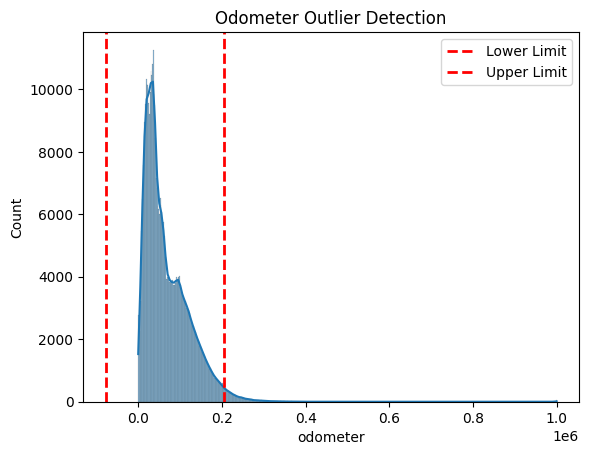

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution
sns.histplot(df['odometer'], kde=True)

# Draw the IQR outlier thresholds
plt.axvline(lower_bound, color='red', linestyle='--', linewidth=2, label='Lower Limit')
plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2, label='Upper Limit')

plt.title('Odometer Outlier Detection')
plt.legend()

In [14]:
# using log version of odometer to reduce skewness

df['odometer_log']=np.log1p(df['odometer'])

In [15]:
# checking outliers of odometer_log using IQR bound

Q1 = df['odometer_log'].quantile(0.25)
Q3 = df['odometer_log'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# clipping outliers on lwr and uppr
df['odometer_log'] = df['odometer_log'].clip(lower_bound,upper_bound)

<Axes: xlabel='odometer_log', ylabel='Count'>

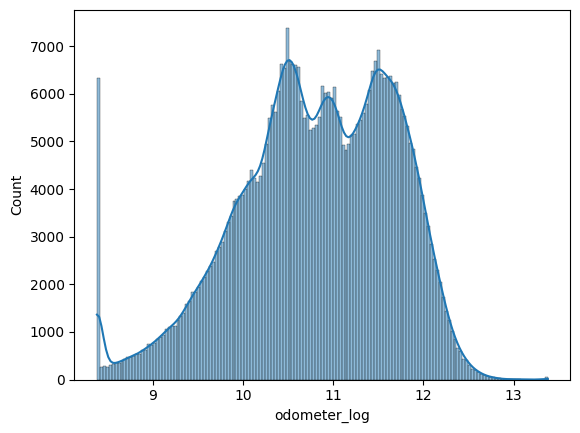

In [16]:
sns.histplot(df['odometer_log'], kde=True)

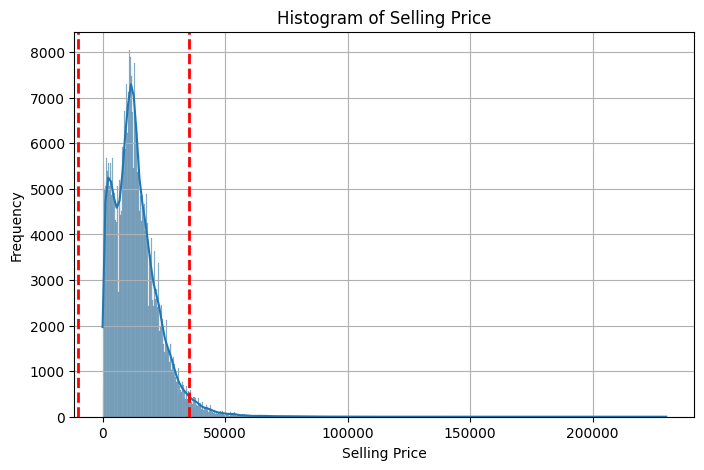

In [17]:
# histogram of selling price

plt.figure(figsize=(8,5))
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Histogram of Selling Price')
sns.histplot(df['sellingprice'],kde=True)
plt.grid(True)

Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3-Q1

sell_lower_bound = Q1-1.5*IQR
sell_upper_bound = Q3+1.5*IQR

plt.axvline(sell_lower_bound, color='red', linestyle='--', linewidth=2, label='Lower Limit')
plt.axvline(sell_upper_bound, color='red', linestyle='--', linewidth=2, label='Upper Limit')

plt.show()

Selling price is clearly right-skewed.  
Concentrated around 5-20 k.  
Very long tail.  


In [18]:
# converting selling price to log

df['sellingprice_log'] = np.log1p(df['sellingprice'])

In [19]:
Q1 = df['sellingprice_log'].quantile(0.25)
Q3 = df['sellingprice_log'].quantile(0.75)
IQR = Q3-Q1

sell_lower_bound_log = Q1-1.5*IQR
sell_upper_bound_log = Q3+1.5*IQR

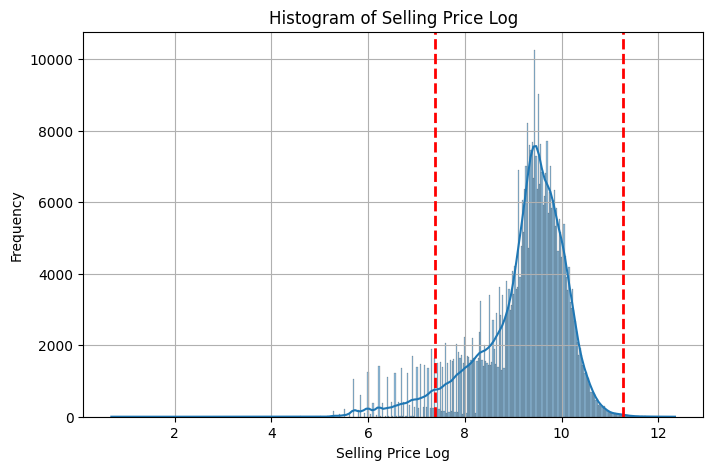

In [20]:
plt.figure(figsize=(8,5))
plt.xlabel('Selling Price Log')
plt.ylabel('Frequency')
plt.title('Histogram of Selling Price Log')
sns.histplot(df['sellingprice_log'],kde=True)
plt.grid(True)

plt.axvline(sell_lower_bound_log, color='red', linestyle='--', linewidth=2, label='Lower Limit')
plt.axvline(sell_upper_bound_log, color='red', linestyle='--', linewidth=2, label='Upper Limit')

plt.show()

In [21]:
df['sellingprice_log'] = df['sellingprice_log'].clip(sell_lower_bound_log,sell_upper_bound_log)

# Exploratory Data Analysis

## Analysis

In [22]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'sellingprice',
       'odometer_log', 'sellingprice_log'],
      dtype='object')

In [23]:
df.nunique()

,0
year,34
make,64
model,839
trim,1822
body,46
transmission,3
state,38
condition,41
odometer,160273
color,20


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447048 entries, 0 to 447047
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              447048 non-null  int64  
 1   make              447048 non-null  object 
 2   model             447048 non-null  object 
 3   trim              447048 non-null  object 
 4   body              447048 non-null  object 
 5   transmission      447048 non-null  object 
 6   state             447048 non-null  object 
 7   condition         447048 non-null  float64
 8   odometer          447048 non-null  float64
 9   color             447048 non-null  object 
 10  interior          447048 non-null  object 
 11  sellingprice      447048 non-null  int64  
 12  odometer_log      447048 non-null  float64
 13  sellingprice_log  447048 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 47.8+ MB


In [25]:
df.describe()

,year,condition,odometer,sellingprice,odometer_log,sellingprice_log
count,447048.000000,447048.000000,447048.000000,447048.000000,447048.000000,447048.000000
mean,2010.035294,3.428382,68351.141177,13609.877854,10.807584,9.242751
std,3.967981,0.940648,53451.503131,9756.832996,0.868794,0.820039
min,1982.000000,1.000000,1.000000,1.000000,8.378357,7.384706
25%,2007.000000,2.700000,28391.000000,6900.000000,10.253863,8.839422
50%,2012.000000,3.600000,52321.000000,12100.000000,10.865172,9.401043
75%,2013.000000,4.200000,99130.250000,18200.000000,11.504200,9.809232
max,2015.000000,5.000000,999999.000000,230000.000000,13.379706,11.263947


In [26]:
df['car_age'] = 2026 - df['year']

In [27]:
# Group by age and body type to get the median selling price [cite: 21, 35]
median_df = df.groupby(['car_age', 'body'])['sellingprice_log'].median().reset_index()

# Filter out low-frequency body types to keep the plot clean
top_bodies = df['body'].value_counts().nlargest(5).index
filtered_median_df = median_df[median_df['body'].isin(top_bodies)]

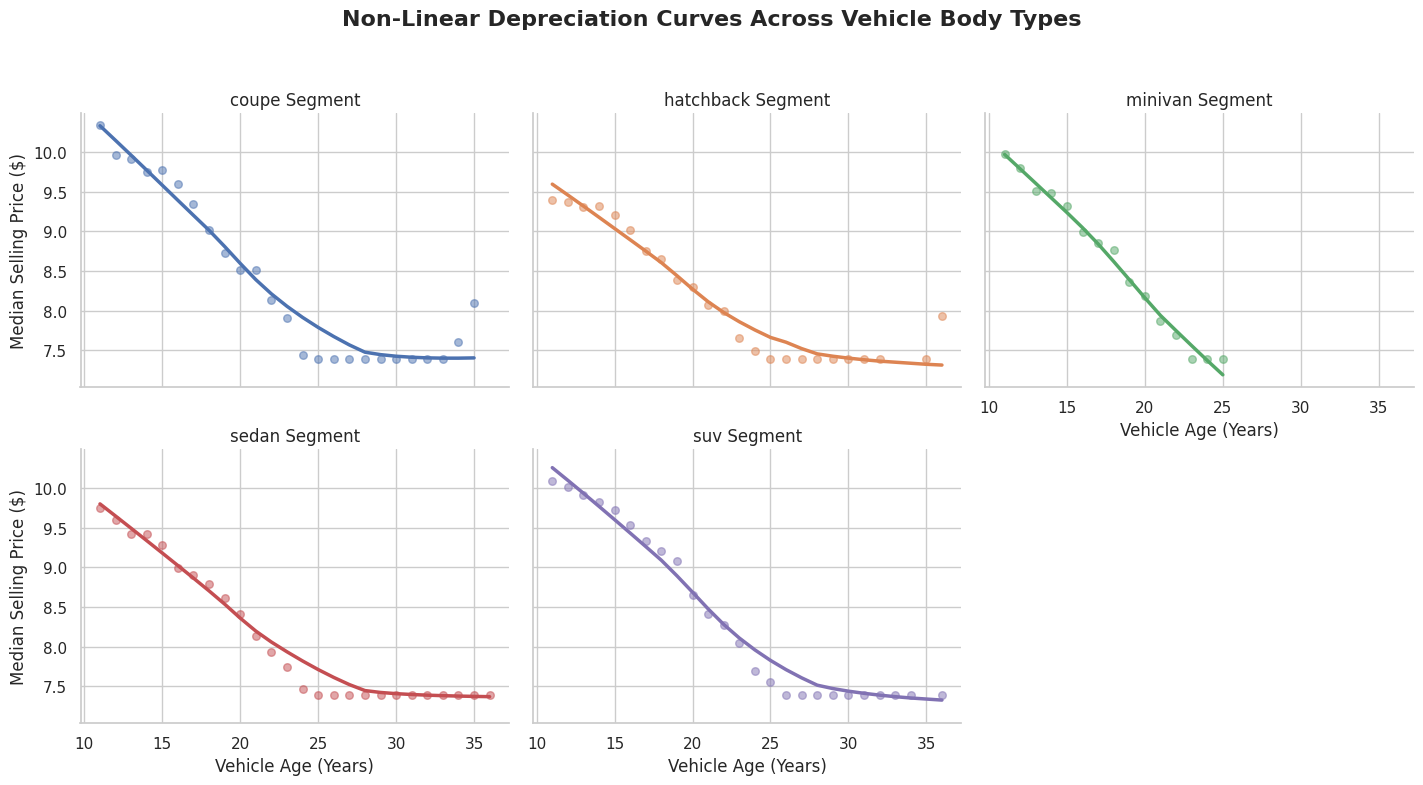

In [28]:
# Set theme for clean visual output
sns.set_theme(style="whitegrid")

# Create faceted plot with a non-linear (lowess) smoother
g = sns.lmplot(
    data=filtered_median_df,
    x="car_age",
    y="sellingprice_log",
    col="body",
    hue="body",
    col_wrap=3,          # Wraps grid into rows of 3
    lowess=True,         # Computes locally weighted linear regression for a smooth GAM-like curve
    scatter_kws={"alpha": 0.5, "s": 30},
    line_kws={"linewidth": 2.5},
    height=4,
    aspect=1.2
)

# Customizing titles and labels
g.set_titles("{col_name} Segment")
g.set_axis_labels("Vehicle Age (Years)", "Median Selling Price ($)")
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Non-Linear Depreciation Curves Across Vehicle Body Types", fontsize=16, fontweight='bold')

plt.show()

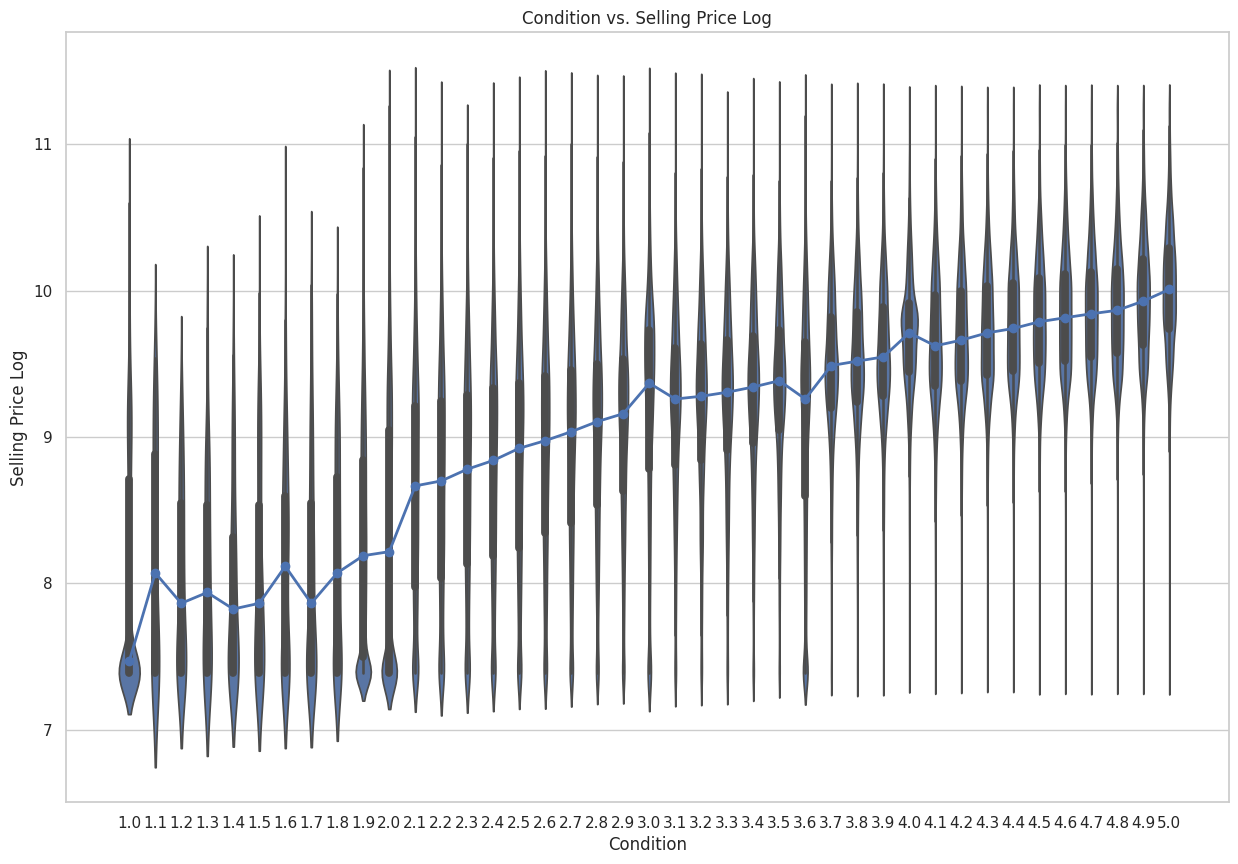

In [29]:
plt.figure(figsize=(15,10))
ax = sns.violinplot(x='condition', y='sellingprice_log', data=df)
medians = df.groupby('condition')['sellingprice_log'].median()
ax.plot(range(len(medians)), medians.values,
        marker='o', linewidth=2)
plt.xlabel('Condition')
plt.ylabel('Selling Price Log')
plt.title('Condition vs. Selling Price Log')
plt.show()

In [30]:
df['usage_intensity'] = df['odometer']/df['car_age']

<Axes: xlabel='usage_intensity', ylabel='sellingprice_log'>

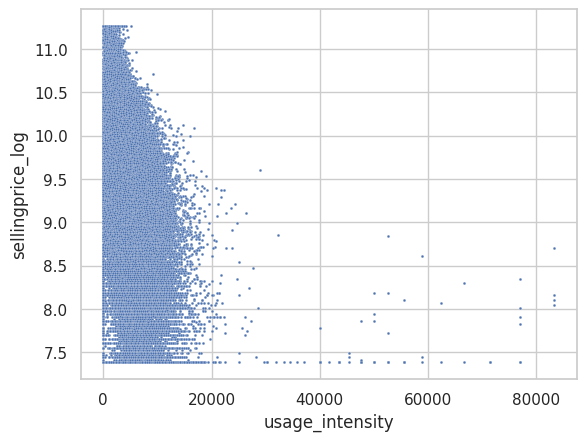

In [31]:
sns.scatterplot(x='usage_intensity', y='sellingprice_log', data=df, s=4)

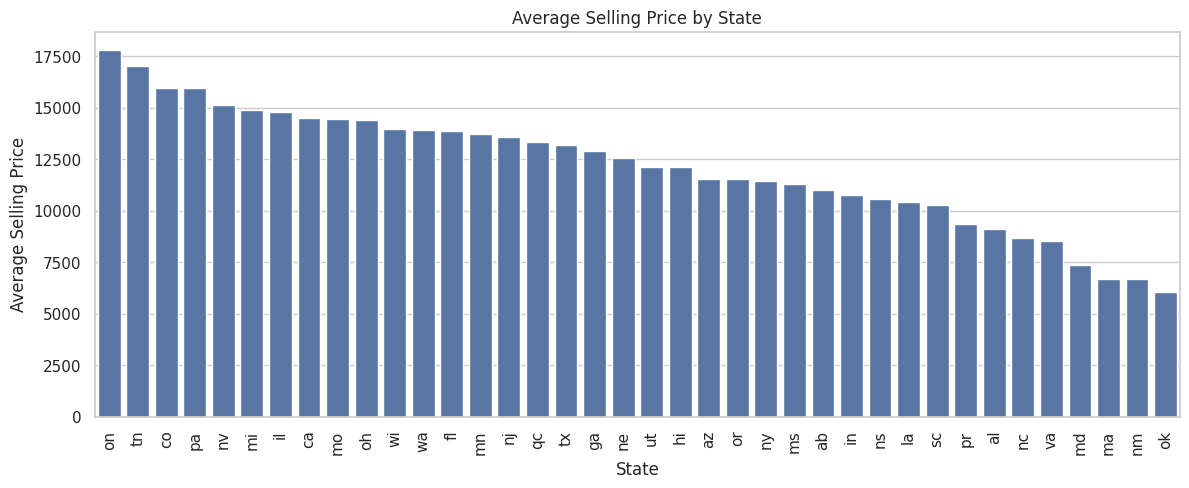

In [32]:
state_avg = (
    df.groupby('state')['sellingprice']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,5))

sns.barplot(
    x=state_avg.index,
    y=state_avg.values
)

plt.xticks(rotation=90)

plt.xlabel("State")
plt.ylabel("Average Selling Price")
plt.title("Average Selling Price by State")

plt.show()

## Feature Engineering

In [33]:
df['overused'] = df['usage_intensity'] > 25000

In [34]:
df['is_vintage'] = df['car_age'] >= 30

In [35]:
df['age_bucket'] = pd.cut(df['car_age'], bins=[0, 3, 7, 12, 20, 25, 100], labels=['new', 'midsized', 'old', 'very_old', 'floor', 'vintage'])

In [36]:
df['years_until_floor'] = np.maximum(0, 25 - df['car_age'])

In [37]:
premium_score = {
    "rolls-royce": 10,
    "bentley": 10,
    "ferrari": 10,
    "lamborghini": 10,

    "aston martin": 9,
    "maserati": 9,
    "porsche": 9,

    "mercedes-benz": 8,
    "bmw": 8,
    "audi": 8,
    "tesla": 8,
    "jaguar": 8,
    "land rover": 8,
    "lexus": 8,

    "cadillac": 7,
    "lincoln": 7,
    "infiniti": 7,
    "acura": 7,
    "volvo": 7,

    "mini": 6,
    "buick": 6,
    "volkswagen": 6,

    "toyota": 5,
    "honda": 5,
    "mazda": 5,
    "subaru": 5,

    "hyundai": 4,
    "kia": 4,
    "nissan": 4,
    "chevrolet": 4,
    "ford": 4,
    "jeep": 4,
    "gmc": 4,

    "dodge": 3,
    "chrysler": 3,
    "mitsubishi": 3,
    "suzuki": 3,
    "pontiac": 3,
    "mercury": 3,
    "saturn": 3,
    "scion": 3,
    "saab": 3,

    "daewoo": 2,
    "geo": 2,
    "oldsmobile": 2,
    "plymouth": 2,
}

In [38]:
df['premium_score'] = df['make'].map(premium_score).fillna(5)

In [39]:
df['is_suv'] = df['model'].str.contains(
    'suv|explorer|tahoe|suburban|x5|q5|q7|rav4|cr-v',
    case=False,
    na=False
).astype(int)

df['is_sports'] = df['model'].str.contains(
    'm3|m5|amg|rs|corvette|mustang|challenger|911',
    case=False,
    na=False
).astype(int)

df['is_hybrid_ev'] = df['model'].str.contains(
    'hybrid|electric|ev|plug-in',
    case=False,
    na=False
).astype(int)

In [40]:
freq = df['make'].value_counts()

df['rare_make'] = (
    df['make']
    .map(freq)
    .lt(10)
    .astype(int)
)

In [41]:
df['miles_per_year'] = df['odometer'] / (2026 - df['year'] + 1)
df['model_popularity'] = df['model'].map(df['model'].value_counts())
brand_means = df.groupby('make')['sellingprice'].transform('mean')

In [42]:
df = df.drop('odometer',axis=1)

In [43]:
df['deprecated'] = df['condition'] <= 2.0

<Axes: >

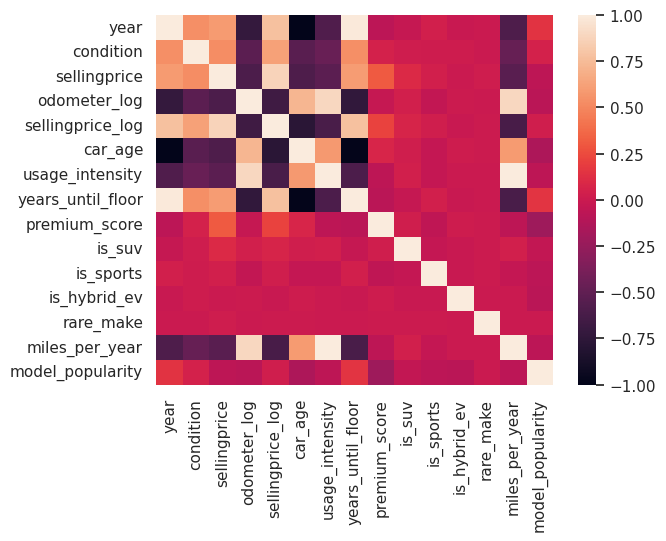

In [44]:
num_cols = df.select_dtypes(include=['number']).columns
corr = df[num_cols].corr()
sns.heatmap(corr)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447048 entries, 0 to 447047
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   year               447048 non-null  int64   
 1   make               447048 non-null  object  
 2   model              447048 non-null  object  
 3   trim               447048 non-null  object  
 4   body               447048 non-null  object  
 5   transmission       447048 non-null  object  
 6   state              447048 non-null  object  
 7   condition          447048 non-null  float64 
 8   color              447048 non-null  object  
 9   interior           447048 non-null  object  
 10  sellingprice       447048 non-null  int64   
 11  odometer_log       447048 non-null  float64 
 12  sellingprice_log   447048 non-null  float64 
 13  car_age            447048 non-null  int64   
 14  usage_intensity    447048 non-null  float64 
 15  overused           447048 non-null

In [46]:
df = df.drop(['miles_per_year','sellingprice'],axis=1)

# Train-Test Split

In [47]:
from sklearn.model_selection import train_test_split

X = df.drop(['sellingprice_log'], axis=1)
y = df['sellingprice_log']

# definitive 80/20 train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

# Make a list of all your string/categorical columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [48]:
train_temp = X_train.copy()
train_temp['sellingprice_log'] = y_train

state_avg_mapping = train_temp.groupby('state')['sellingprice_log'].mean().to_dict()
global_mean = y_train.mean() # safe fallback value

X_train['state_avg_price'] = X_train['state'].map(state_avg_mapping).fillna(global_mean)
X_val['state_avg_price'] = X_val['state'].map(state_avg_mapping).fillna(global_mean)

brand_avg_mapping = train_temp.groupby('make')['sellingprice_log'].mean().to_dict()

X_train['brand_avg_price'] = X_train['make'].map(brand_avg_mapping).fillna(global_mean)
X_val['brand_avg_price'] = X_val['make'].map(brand_avg_mapping).fillna(global_mean)

# Training Model

In [49]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [ ]:
!pip install optuna

In [50]:
import catboost
from catboost import CatBoostRegressor

In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.metrics import root_mean_squared_error

# Turn off verbose messages from optuna logging for a cleaner output
optuna.logging.set_verbosity(optuna.logging.INFO)

def objective(trial):
    # Match the hyperparameter exploration space you used in RandomizedSearchCV
    params = {
        'iterations': trial.suggest_categorical('iterations', [500, 1000, 1500]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 9, step=2),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 50
    }

    # Initialize and fit on training split
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, cat_features=categorical_features, verbose=100)

    # Evaluate score on your clean validation split
    preds = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, preds)
    return rmse

# Create an Optuna study optimization run
study = optuna.create_study(direction='minimize')
print("Starting Optuna Hyperparameter Optimization Trials...")
study.optimize(objective, n_trials=100) # Matches your original 10 iteration setups

print("\nWinning Parameters Found by Optuna:", study.best_params)
print(f"Best Validation RMSE via Tuning: {study.best_value:,.2f}")

[I 2026-05-27 12:14:45,026] A new study created in memory with name: no-name-dcf71bcf-2683-451a-bb65-425cd0d49f10


Starting Optuna Hyperparameter Optimization Trials...
0:	learn: 0.8126430	total: 905ms	remaining: 7m 31s
100:	learn: 0.3889278	total: 1m	remaining: 4m
200:	learn: 0.2954382	total: 1m 49s	remaining: 2m 42s
300:	learn: 0.2715101	total: 2m 42s	remaining: 1m 47s
400:	learn: 0.2606787	total: 3m 34s	remaining: 53s
499:	learn: 0.2533433	total: 4m 26s	remaining: 0us


[I 2026-05-27 12:19:14,482] Trial 0 finished with value: 0.2523809308503532 and parameters: {'iterations': 500, 'learning_rate': 0.013991110513055051, 'depth': 5, 'l2_leaf_reg': 9}. Best is trial 0 with value: 0.2523809308503532.


0:	learn: 0.8110344	total: 783ms	remaining: 6m 30s
100:	learn: 0.3471915	total: 1m 23s	remaining: 5m 28s
200:	learn: 0.2656160	total: 2m 37s	remaining: 3m 54s
300:	learn: 0.2472414	total: 3m 55s	remaining: 2m 35s
400:	learn: 0.2373775	total: 5m 14s	remaining: 1m 17s
499:	learn: 0.2294441	total: 6m 33s	remaining: 0us


[I 2026-05-27 12:25:51,713] Trial 1 finished with value: 0.22855029058475804 and parameters: {'iterations': 500, 'learning_rate': 0.01582779859437407, 'depth': 7, 'l2_leaf_reg': 5}. Best is trial 1 with value: 0.22855029058475804.


...

0:	learn: 0.7799198	total: 936ms	remaining: 15m 35s
100:	learn: 0.2299413	total: 1m 32s	remaining: 13m 40s
200:	learn: 0.2071361	total: 3m 4s	remaining: 12m 14s
300:	learn: 0.1961456	total: 4m 36s	remaining: 10m 43s
400:	learn: 0.1890666	total: 6m 9s	remaining: 9m 11s
500:	learn: 0.1845034	total: 7m 41s	remaining: 7m 39s
600:	learn: 0.1815780	total: 9m 14s	remaining: 6m 7s
700:	learn: 0.1791269	total: 10m 47s	remaining: 4m 36s
800:	learn: 0.1771223	total: 12m 20s	remaining: 3m 3s
900:	learn: 0.1755071	total: 13m 54s	remaining: 1m 31s
999:	learn: 0.1740681	total: 15m 27s	remaining: 0us


[I 2026-05-27 16:03:00,528] Trial 18 finished with value: 0.1777054744255211 and parameters: {'iterations': 1000, 'learning_rate': 0.0647507863705242, 'depth': 8, 'l2_leaf_reg': 7}. Best is trial 10 with value: 0.1735138417980732.


0:	learn: 0.7940211	total: 809ms	remaining: 13m 27s
100:	learn: 0.2528088	total: 1m 15s	remaining: 11m 13s
200:	learn: 0.2272543	total: 2m 32s	remaining: 10m 6s
300:	learn: 0.2142282	total: 3m 49s	remaining: 8m 52s
400:	learn: 0.2057145	total: 5m 7s	remaining: 7m 38s
500:	learn: 0.1995739	total: 6m 23s	remaining: 6m 22s
600:	learn: 0.1949156	total: 7m 39s	remaining: 5m 5s
700:	learn: 0.1913454	total: 8m 57s	remaining: 3m 49s
800:	learn: 0.1886170	total: 10m 14s	remaining: 2m 32s
900:	learn: 0.1862670	total: 11m 33s	remaining: 1m 16s


[W 2026-05-27 16:15:49,907] Trial 19 failed with parameters: {'iterations': 1000, 'learning_rate': 0.04306549673989082, 'depth': 7, 'l2_leaf_reg': 1} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_3408/3254273875.py", line 23, in objective
    model.fit(X_train, y_train, cat_features=categorical_features, verbose=100)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 2716, in _fit

KeyboardInterrupt: 

# Evaluation

In [ ]:
import joblib
from sklearn.metrics import root_mean_squared_error
best_params =study.best_params
final_model = CatBoostRegressor(
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    loss_function='RMSE',
    random_seed=42,
    verbose=0
)
final_model.fit(X_train, y_train, cat_features=categorical_features)
tuned_preds = final_model.predict(X_val)
tuned_rmse = root_mean_squared_error(y_val, tuned_preds)

# Export your clean model binary file
joblib.dump(final_model, "model_AyushRaigandhi.pkl")
print("\nFinal tuned model artifact successfully saved to disk!")

/tmp/ipykernel_3408/2845055959.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


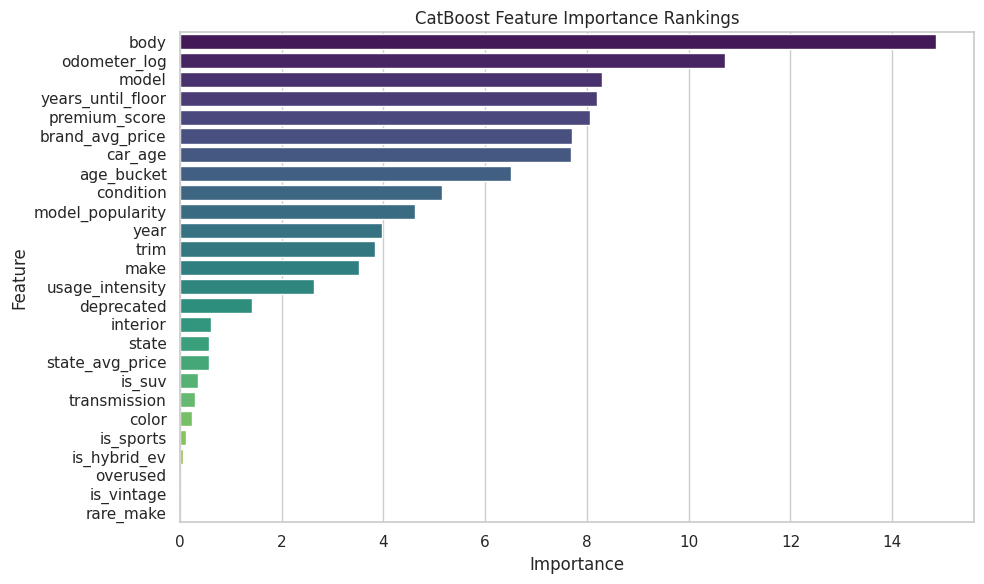

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = final_model.get_feature_importance()
fi_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('CatBoost Feature Importance Rankings')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'color', 'interior', 'odometer_log', 'sellingprice_log',
       'car_age', 'usage_intensity', 'overused', 'is_vintage', 'age_bucket',
       'years_until_floor', 'premium_score', 'is_suv', 'is_sports',
       'is_hybrid_ev', 'rare_make', 'model_popularity', 'deprecated'],
      dtype='object')

In [ ]:
# model predicts log(sellingprice)

rmse = root_mean_squared_error(np.expm1(y_val), np.expm1(tuned_preds))
print(rmse)

2080.364306057052


In [ ]:
mappings = {
    'state_avg_mapping': state_avg_mapping,
    'brand_avg_mapping': brand_avg_mapping,
    'model_popularity':  df['model'].value_counts().to_dict(),
    'make_freq':         df['make'].value_counts().to_dict(),
    'global_mean':       global_mean,
    'feature_columns':   X_train.columns.tolist(), 
}
joblib.dump(mappings, "mappings_AyushRaigandhi.pkl")